knn ---> FarePerPerson, IsAlone, AgeGroup, FareGroup

In [1]:
from final_data import titanic_data, titanic_test_data, titanic_gender_submission
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
data = titanic_data()
X = data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FamilySize']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=19)

In [3]:
print(X_train.dtypes)

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
Gender         object
FamilySize      int64
dtype: object


In [4]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
]

categorical_features = [
    'Embarked',
    'Gender',
]

In [5]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipe_line = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
], verbose=True)

pipe_line.fit(X_train, y_train)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.1s


,steps,"[('preprocessor', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,True
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
param_grid = {
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2, 3, 4, 6],
    'knn__leaf_size': [20, 30, 50, 70],
}

In [7]:
grid = GridSearchCV(estimator=pipe_line, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')
grid.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing knn, total=   0.0s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...

,estimator,Pipeline(step... verbose=True)
,param_grid,"{'knn__algorithm': ['auto', 'ball_tree', ...], 'knn__leaf_size': [20, 30, ...], 'knn__p': [1, 2, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [8]:
grid.best_params_

{'knn__algorithm': 'auto',
 'knn__leaf_size': 50,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [9]:
grid.best_score_

np.float64(0.7824448419797256)

In [14]:
test_data = titanic_test_data()
gender_submission_data = titanic_gender_submission()
X_test = test_data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y_test = gender_submission_data['Survived'] 

In [15]:
test_accuracy = grid.score(X_test, y_test)
test_accuracy

0.8349282296650717

In [16]:
pred = grid.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[225  41]
 [ 28 124]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       266
           1       0.75      0.82      0.78       152

    accuracy                           0.83       418
   macro avg       0.82      0.83      0.82       418
weighted avg       0.84      0.83      0.84       418



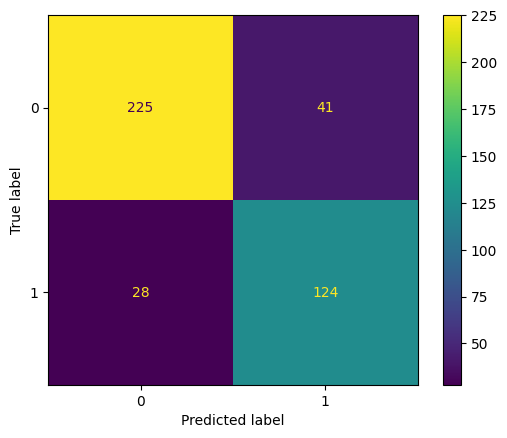

In [17]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred), display_labels=grid.classes_).plot()